In [158]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from pathlib import Path

DATA_PATH = Path("../data/netflix_titles.csv")
df = pd.read_csv(DATA_PATH)

In [159]:
# check df
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Cleaning

In [160]:
# info about the df
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.8 MB


In [161]:
# shape of df
df.shape

(8807, 12)

In [162]:
# checking missing values
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [163]:
# fix column names
df.columns = df.columns.str.replace("_", " ")
df.columns = df.columns.str.capitalize()

In [164]:
# strip whitespace from object columns
for col in df.select_dtypes(include="str"):
    df[col] = df[col].str.strip()

In [165]:
# convert date
df["Date added"] = pd.to_datetime(df["Date added"], errors="coerce", format="%B %d, %Y")

In [166]:
# duration extraction 
df["Duration num"] = df["Duration"].str.extract(r'(\d+)') 
df["Duration num"] = df["Duration num"].astype("Int64")

In [167]:
# rating categories 
rating_categories = { 
    "TV-Y": "Kids", 
    "TV-Y7": "Kids", 
    "G": "Kids", 
    "TV-G": "Kids", 
    "PG": "Teens", 
    "PG-13": "Teens", 
    "TV-PG": "Teens", 
    "TV-14": "Teens", 
    "R": "Adults", 
    "TV-MA": "Adults", 
    "NC-17": "Adults", 
} 
df["Rating category"] = df["Rating"].map(rating_categories)

In [168]:
# create exploded dataframe
df_exploded = df.copy() 

# countries 
df_exploded["Country"] = df_exploded["Country"].str.split(",") 
df_exploded = df_exploded.explode("Country") 
df_exploded["Country"] = df_exploded["Country"].str.strip() 

# genres 
df_exploded["Listed in"] = df_exploded["Listed in"].str.split(",") 
df_exploded = df_exploded.explode("Listed in") 
df_exploded["Listed in"] = df_exploded["Listed in"].str.strip()

# directors 
df_exploded["Director"] = df_exploded["Director"].str.split(",") 
df_exploded = df_exploded.explode("Director") 
df_exploded["Director"] = df_exploded["Director"].str.strip()

# Exploratory Data Analysis (EDA)

## Movies vs Tv Shows

In [169]:
# counts
type_counts = df.Type.value_counts()
type_counts

Type
Movie      6131
TV Show    2676
Name: count, dtype: int64

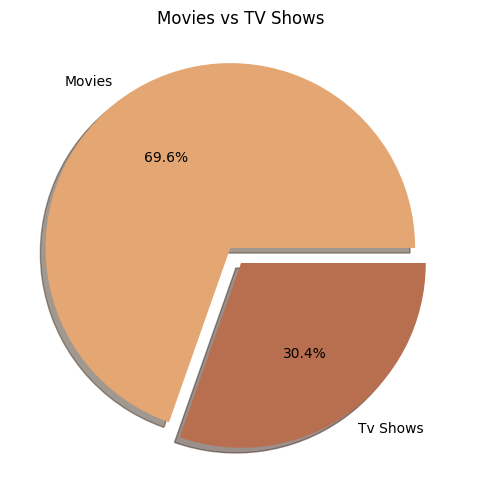

In [170]:
# percentages 
type_counts_perc = df["Type"].value_counts(normalize=True) * 100 
type_counts_perc_values = [type_counts_perc["Movie"], type_counts_perc["TV Show"]] 
labels = ["Movies", "Tv Shows"]
type_colors = ["#e4a672", "#b86f50"]

plt.figure(figsize=(8, 6)) 
plt.pie(type_counts_perc_values, labels=labels, autopct="%1.1f%%", colors=type_colors, explode=(0.1, 0), shadow=True) 
plt.title("Movies vs TV Shows")
plt.savefig("../images/movies_and_tv_shows_perc.png", bbox_inches="tight", dpi=300)
plt.show()

## Content Growth Over Time

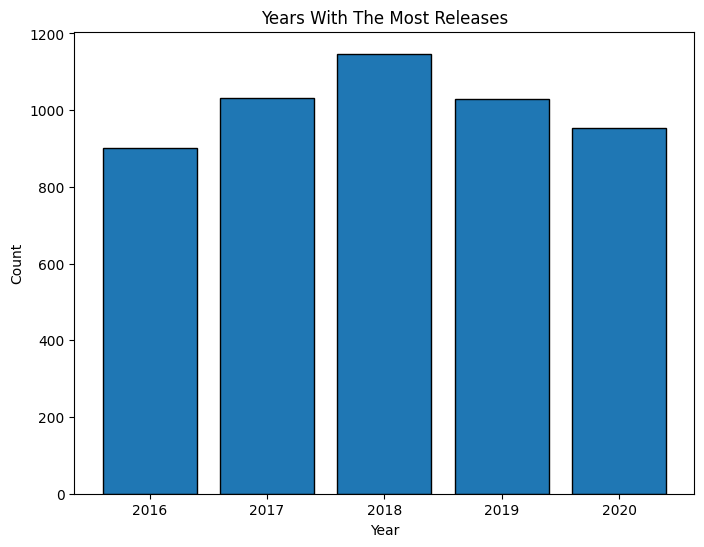

In [171]:
most_releases = (df.groupby("Release year").size().nlargest(5)) 
plt.figure(figsize=(8, 6)) 
plt.bar(most_releases.index, most_releases.values, edgecolor="black") 
plt.title("Years With The Most Releases") 
plt.xlabel("Year") 
plt.ylabel("Count")
plt.savefig("../images/content_growth_over_time.png", bbox_inches="tight", dpi=300)
plt.show()

Tv shows after 2005

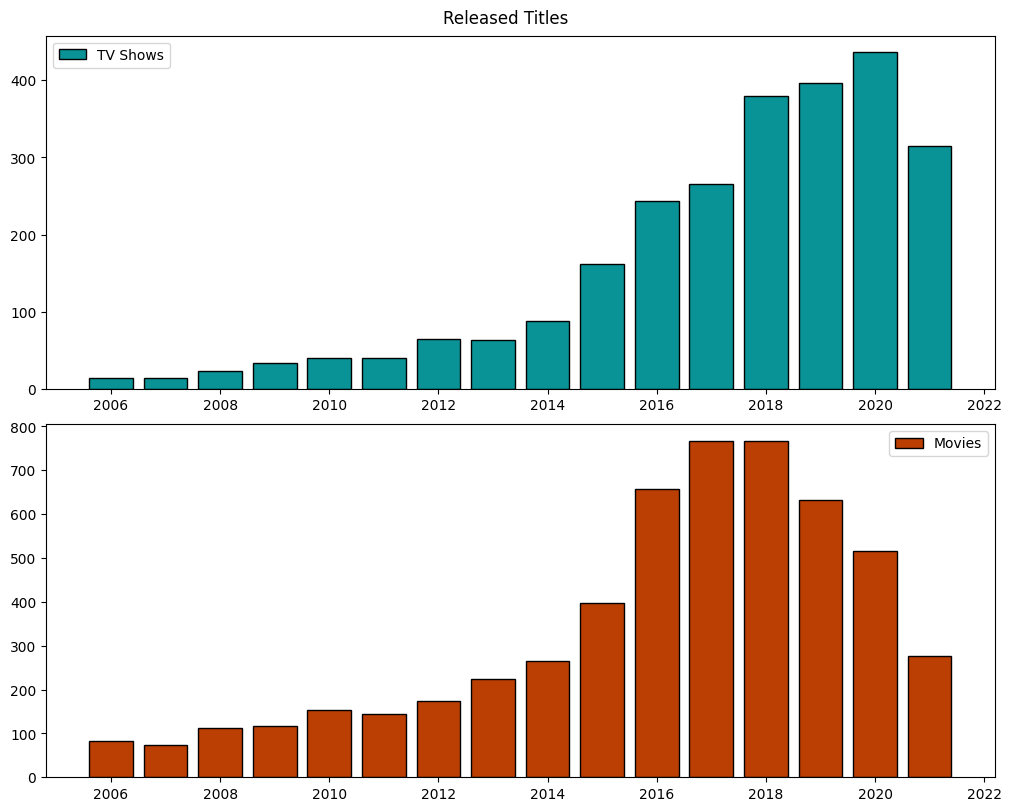

In [172]:
tv_shows_df = (df[(df["Type"] == "TV Show") & (df["Release year"] > 2005)].groupby("Release year").size()) 
movies_df = (df[(df["Type"] == "Movie") & (df["Release year"] > 2005)].groupby("Release year").size()) 

fig, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(10, 8)) 
axes[0].bar(tv_shows_df.index, tv_shows_df.values, color="#0A9396", edgecolor="black", label="TV Shows") 
axes[0].legend() 
axes[1].bar(movies_df.index, movies_df.values, color="#BB3E03", edgecolor="black", label="Movies") 
axes[1].legend()
plt.suptitle("Released Titles") 
plt.savefig("../images/released_titles.png", bbox_inches="tight", dpi=300)
plt.show()

## Country Analysis

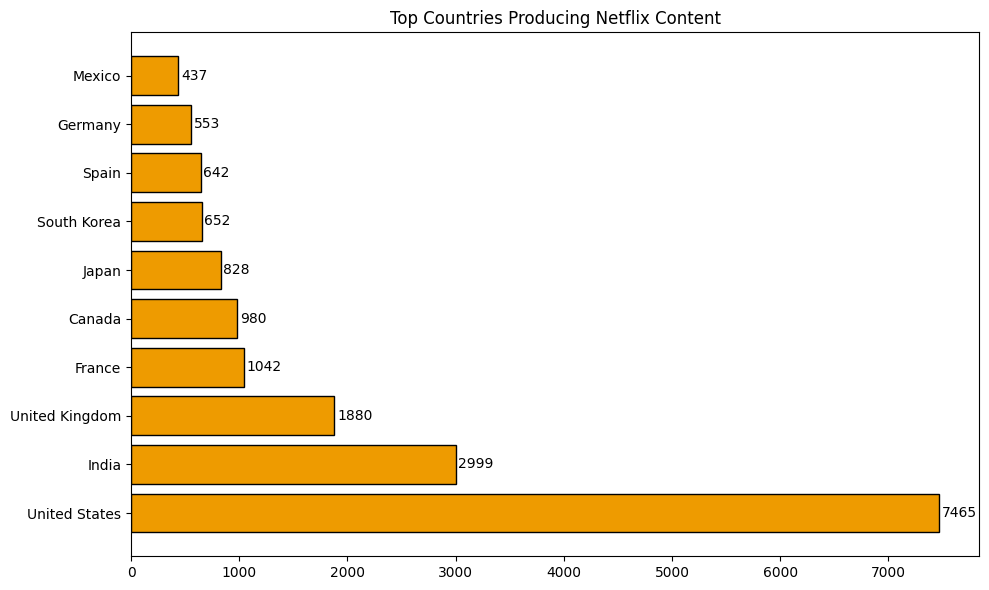

In [173]:
top_ten_countries = (df_exploded["Country"].value_counts().nlargest(10)) 

plt.figure(figsize=(10, 6)) 
bar_h = plt.barh(top_ten_countries.index, top_ten_countries.values, color="#EE9B00", edgecolor="black") 
plt.bar_label(bar_h, padding=2) 
plt.title("Top Countries Producing Netflix Content") 
plt.tight_layout()
plt.savefig("../images/top_countries_producing_content.png", bbox_inches="tight", dpi=300)
plt.show()

Country focus by type

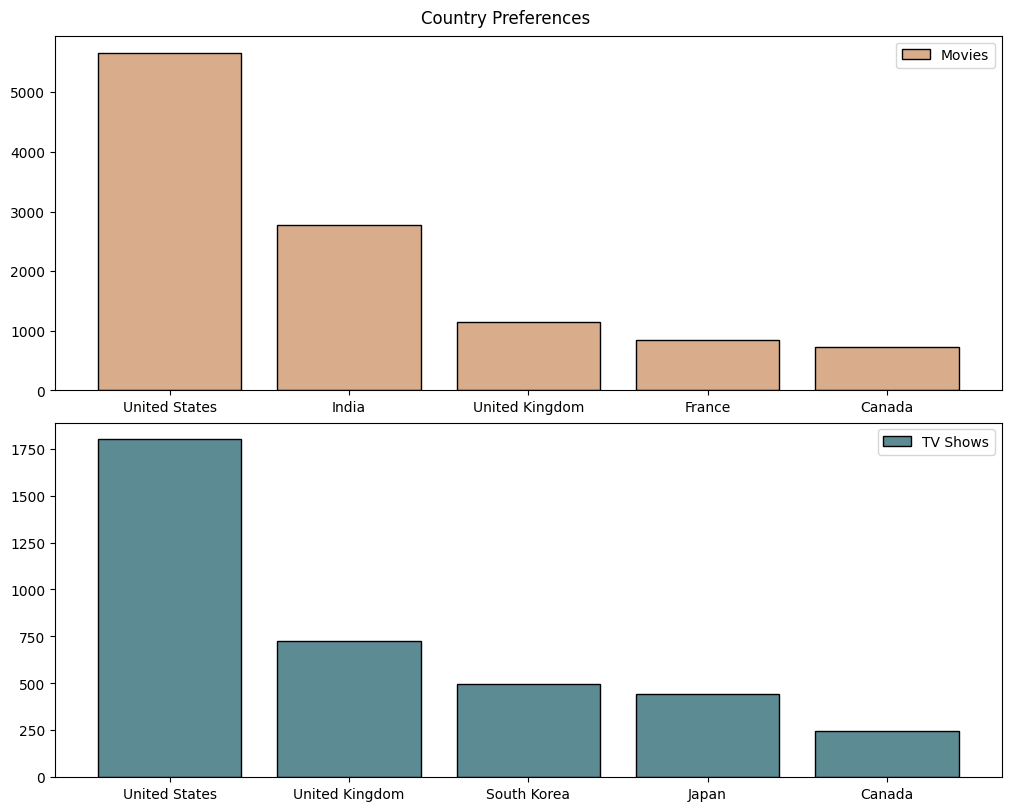

In [174]:
country_type = (df_exploded.groupby(["Country", "Type"]).size().unstack(fill_value=0)) 
country_type_movie_largest = (country_type["Movie"].nlargest(5)) 
country_type_tv_largest = (country_type["TV Show"].nlargest(5)) 

fig, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(10, 8)) 
axes[0].bar(country_type_movie_largest.index, country_type_movie_largest.values, label="Movies", color="#d9ac8b", edgecolor="black") 
axes[0].legend() 
axes[1].bar(country_type_tv_largest.index, country_type_tv_largest.values, label="TV Shows", color="#5c8b93", edgecolor="black") 
axes[1].legend() 
plt.suptitle("Country Preferences") 
plt.show()

## Ratings analysis

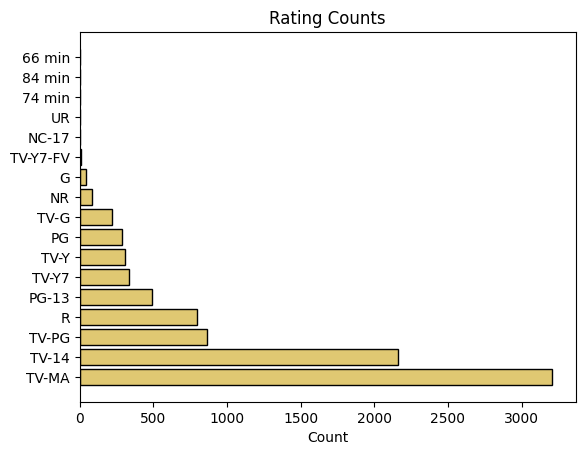

In [175]:
ratings = df["Rating"].value_counts() 

plt.barh(ratings.index, ratings.values, color="#e0c872", edgecolor="black") 
plt.title("Rating Counts") 
plt.xlabel("Count")
plt.savefig("../images/rating_counts.png", bbox_inches="tight", dpi=300)
plt.show()

Rating categories

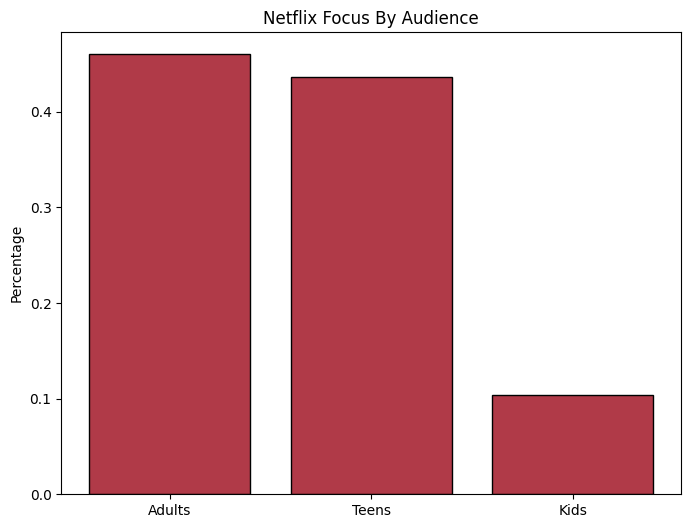

In [176]:
# rating categories 
rating_cats = (df["Rating category"].value_counts(normalize=True)) 

plt.figure(figsize=(8, 6)) 
plt.bar(rating_cats.index, rating_cats.values, color="#b03a48", edgecolor="black") 
plt.title("Netflix Focus By Audience") 
plt.ylabel("Percentage") 
plt.show()

## Duration analysis

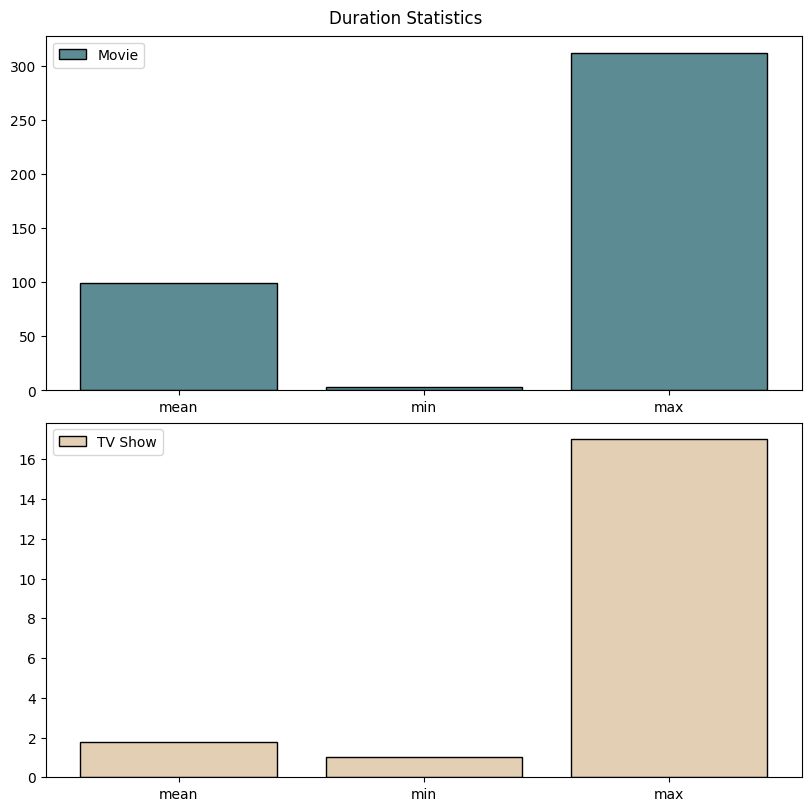

In [177]:
movies = df[df["Type"] == "Movie"] 
tv_shows = df[df["Type"] == "TV Show"] 
movies_stats = (movies["Duration num"].agg(["mean", "min", "max"])) 
tv_shows_stats = (tv_shows["Duration num"].agg(["mean", "min", "max"])) 

fig, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(8, 8)) 
axes[0].bar(movies_stats.index, movies_stats.values, color="#5c8b93", edgecolor="black", label="Movie") 
axes[0].legend() 
axes[1].bar(tv_shows_stats.index, tv_shows_stats.values, color="#e3cfb4", edgecolor="black", label="TV Show") 
axes[1].legend() 
plt.suptitle("Duration Statistics")
plt.savefig("../images/duration_stats.png", bbox_inches="tight", dpi=300)
plt.show()

## Genre analysis

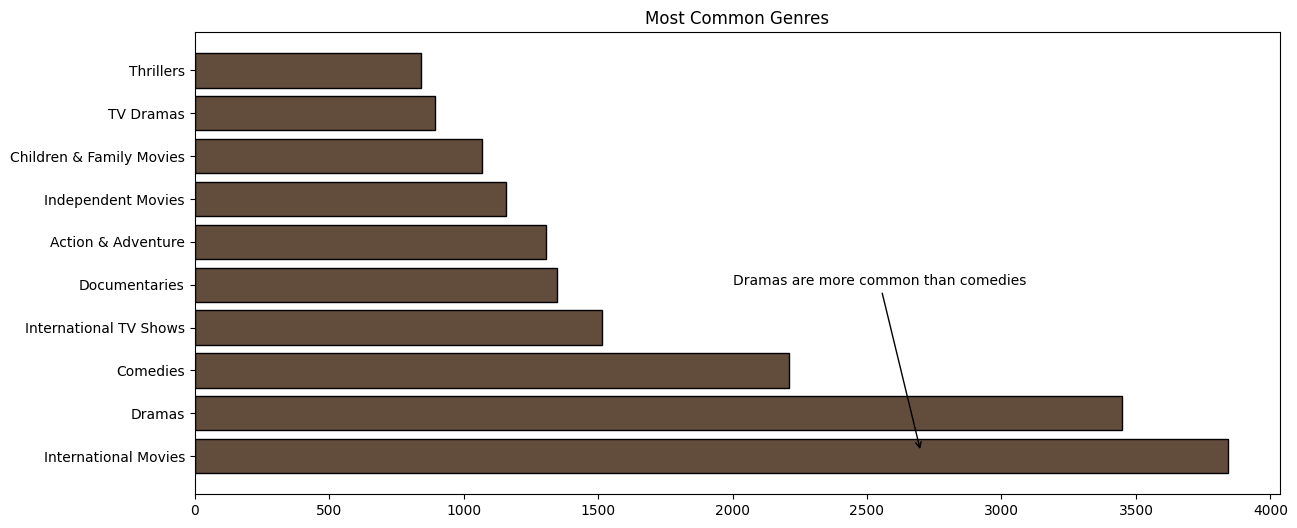

In [178]:
most_common_genres = (df_exploded["Listed in"].value_counts().nlargest(10)) 

figure(figsize=(14, 6)) 
plt.barh(most_common_genres.index, most_common_genres.values, color="#624c3c", edgecolor="black") 
plt.annotate(text="Dramas are more common than comedies", xytext=(2000, 4), xy=(2700, 0.1), arrowprops=dict(arrowstyle="->")) 
plt.title("Most Common Genres")
plt.savefig("../images/most_common_genres.png", bbox_inches="tight", dpi=300)
plt.show()

## Director analysis

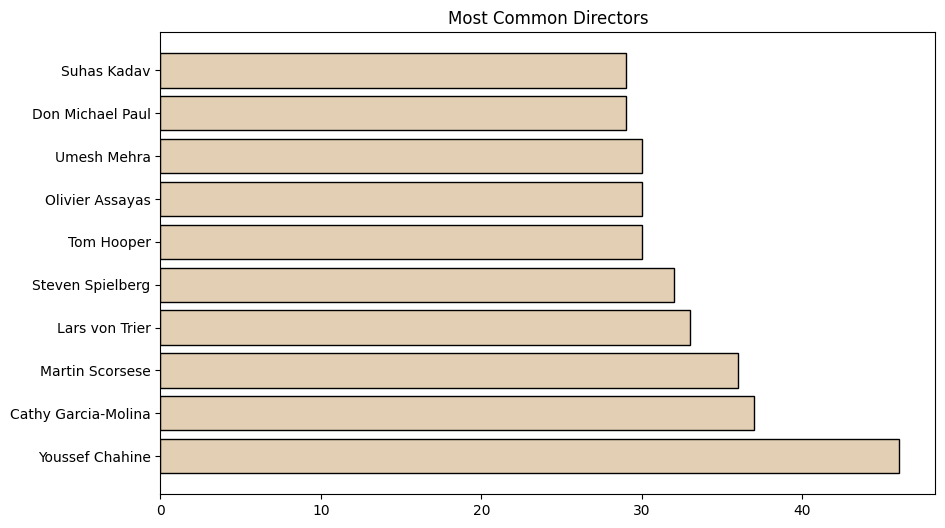

In [179]:
most_common_directors = (df_exploded["Director"].value_counts().nlargest(10)) 

plt.figure(figsize=(10, 6)) 
plt.barh(most_common_directors.index, most_common_directors.values, color="#e3cfb4", edgecolor="black") 
plt.title("Most Common Directors") 
plt.show()

Directors working on both

In [180]:
director_types = (df_exploded .groupby("Director")["Type"].nunique()) 
both = director_types[director_types == 2] 
both = both.reset_index() 

print(both.head(20))

                    Director  Type
0           Abhishek Chaubey     2
1        Alastair Fothergill     2
2              Alban Teurlai     2
3          Alessandro Angulo     2
4                 Andrew Tan     2
5             Anurag Kashyap     2
6        B. V. Nandini Reddy     2
7                  BB Sasore     2
8              Bejoy Nambiar     2
9               Billy Corben     2
10             Brad Anderson     2
11            Bunmi Ajakaiye     2
12            Cosima Spender     2
13                Dan Forrer     2
14             Daniel Kontur     2
15                David Ayer     2
16  Elaine McMillion Sheldon     2
17                  Eli Roth     2
18             Estela Renner     2
19               Faris Godus     2


## Content growth by country

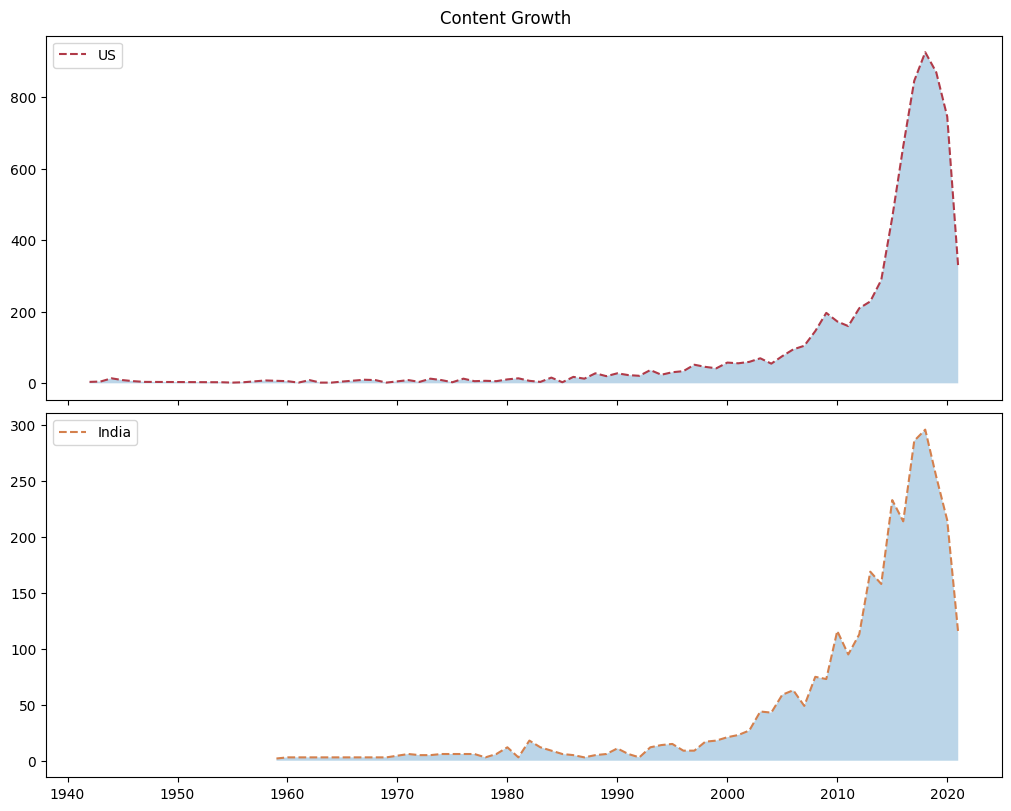

In [181]:
us_counts_by_year = (df_exploded[df_exploded["Country"] == "United States"].groupby("Release year").size()) 
india_counts_by_year = (df_exploded[df_exploded["Country"] == "India"].groupby("Release year").size()) 

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, constrained_layout=True, sharex=True, figsize=(10, 8)) 
ax1.plot(us_counts_by_year.index, us_counts_by_year.values, linewidth=1.5, linestyle="dashed", color="#b03a48", label="US") 
ax1.fill_between(us_counts_by_year.index, us_counts_by_year.values, alpha=0.3) 
ax1.legend() 
ax2.plot(india_counts_by_year.index, india_counts_by_year.values, linewidth=1.5, linestyle="dashed", color="#d4804d", label="India") 
ax2.fill_between(india_counts_by_year.index, india_counts_by_year.values, alpha=0.3) 
ax2.legend() 
plt.suptitle("Content Growth")
plt.savefig("../images/content_growth_us_vs_india.png", bbox_inches="tight", dpi=300) 
plt.show()

# Exploratory Data Analysis Conclusions

1.	Movies make up 70% of Netflix content, with the rest being Tv Shows. 
2.	The number of titles increased significantly after 2005, especially between 2016 and 2020, suggesting rapid expansion of Netflix’s catalog.
3.	The US appears most frequently as a production country in the dataset.
4.	The United States dominates both movie and TV show production counts in the dataset. India ranks second in movie counts, while the United Kingdom ranks second in TV shows.
5.	Netflix content is largely targeted toward mature and teen audiences, with TV-MA and TV-14 being the most common ratings. More than 40% of the content is for adults, ≈40% is for teens and ≈10% for kids.
6.	A Netflix movie lasts, on average, 100 minutes while a tv show lasts, on average, ≈2 seasons.
7.	International movies, dramas and comedies are the most common genres on the platform. 
8.	The most common directors are Youssef Chahine, Cathy Garcia-Molina and Martin Scorsese.
9.	Both the US and India show strong growth in title counts over time, although the US consistently has a larger number of titles.